# Vial con multiple blindaje


## Tabla de contenidos

1. [Geometría del sistema](#1-geometría-del-sistema)
   - Capas radiales y axiales
   - Vial de vidrio y fuente
   - Detectores grupo A y B

2. [Materiales, detectores y fuente](#2-materiales-detectores-y-fuente)
   - Materiales personalizados
   - Configuración de la fuente

3. [Análisis de resultados](#3-análisis-de-resultados)
   - Lectura de datos
   - Consideraciones metodológicas
   - 3.1 Mapas de calor
   - 3.2 Validación estadística
   - 3.3 Dosis por detector
   - 3.4 Atenuación a través del blindaje
     - Perfil de dosis vs posición
     - Transmitancia

Este trabajo consiste en la emulación de un sistema radiactivo que modela una disolución de 10 mL de agua con el radiofármaco F-18 FDG. Debido a su naturaleza radiactiva, el vial requiere medidas estrictas de seguridad para su transporte. Se considera el caso de transporte nacional con una actividad de 10 mCi. Las dimensiones del blindaje se obtuvieron de la ficha técnica del fabricante. La simulación se realizó con GATE versión 10.

Este Jupyter no contiene la simulación, sino que contiene los códigos necesarios para evaluar los resultados que se consideraron pertinentes, por lo que es importante tener bien localizados todos los resultados que se obtuvieron corriendo el código de GATE. Se hará un desglose general de las caracteristicas del código dividido en secciones.

## 1. Geometría del sistema

El blindaje que requiere este radiofármaco consiste en una capa gruesa de plomo recubierta de acero inoxidable, al revisar la ficha técnica podemos resumir las dimensiones que se necesitan modelar en las siguientes tablas.

**Tabla 1 — Capas radiales** (medidas desde el eje central del cilindro)

| Capa | Radio interno | Radio externo | Espesor |
|---|---|---|---|
| Cavidad de aire | 0 mm | 16.5 mm | 16.5 mm |
| Blindaje de plomo | 16.5 mm | 48.5 mm | **32.0 mm** |
| Carcasa de acero inoxidable | 48.5 mm | 50.5 mm | 2.0 mm |

**Tabla 2 — Capas axiales** (medidas desde el centro del contenedor hacia cada tapa)

| Capa | Desde | Hasta | Espesor |
|---|---|---|---|
| Cavidad de aire | 0 mm | 37.0 mm | 37.0 mm |
| Blindaje de plomo (tapa) | 37.0 mm | 55.75 mm | 18.75 mm |
| Carcasa de acero inoxidable (tapa) | 55.75 mm | 57.75 mm | 2.0 mm |



**Tabla 3 — Vial de vidrio y fuente de agua**

| Elemento | Radio | Altura/espesor | Posición (centro en Z) |
|---|---|---|---|
| Pared del vial | 11.0 – 12.5 mm | 45.0 mm | z = −13.0 mm |
| Fondo del vial | 0 – 11.0 mm | 1.5 mm | z = −36.25 mm |
| Agua (10 mL, F-18 FDG) | 0 – 11.0 mm | 26.3 mm | z = −22.35 mm |




Algunas dimensiones presentan ligeras variaciones respecto a la ficha técnica, del orden de pocos milímetros, introducidas para evitar solapamientos geométricos en la simulación.

## 2. Materiales, detectores y fuente

Las librerías de GATE no tienen conocimiento de muchos materiales los cuales pueden resultar necesarios de simular, sin embargo, se permite crear materiales usando algunos de sus datos atómicos y químicos, en este caso debimos crear el vidrio, el plomo y el acero, en la siguiente tabla se ven las características utilizadas para cada uno:

### Materiales utilizados en la simulación

**Tabla — Materiales personalizados** (definidos con `add_material_nb_atoms`, proporción por número de átomos)

| Material | Composición (elementos, proporción atómica) | Densidad | Dónde se usa |
|---|---|---|---|
| `StainlessSteel` | Fe : Cr : Ni = 70 : 20 : 10 | 7.81 g/cm³ | Carcasa exterior (pared, base y tapa de acero) |
| `Lead` | Pb (puro) | 11.4 g/cm³ | Blindaje principal (pared, base y tapa de plomo) |


Los demás materiales usados ya están establecidos previamente. 



Para cuantificar la dosis recibida en posiciones clave, se definen actores de dosis que registran la energía depositada en cada detector. 

**Tabla 4 — Detectores: grupo A (contacto con el contenedor)**

| Detector | Dimensiones | Material | Posición | Criterio |
|---|---|---|---|---|
| `det_palma` | 95×1×70 mm | G4_TISSUE_SOFT_ICRP | Y = −55 mm | Simula la palma apoyada sobre el contenedor |
| `det_dedos` | 1×40×70 mm | G4_TISSUE_SOFT_ICRP | X = +50 mm, Y = −35 mm | Simula los dedos rodeando el contenedor |

**Tabla 5 — Detectores: grupo B (técnico a 15 cm de la superficie)**

| Detector | Dimensiones | Material | Posición | Criterio |
|---|---|---|---|---|
| `det_torso` | 1×300×400 mm | G4_TISSUE_SOFT_ICRP | X = −200.5 mm | 15 cm desde la superficie externa (radio 50.5 mm) |
| `det_cabeza` | 1×130×170 mm | G4_TISSUE_SOFT_ICRP | X = −200.5 mm, Z = +450 mm | Misma distancia, a la altura de la cabeza |
| `det_manos` | 1×80×150 mm | G4_TISSUE_SOFT_ICRP | X = −200.5 mm, Y = +200 mm, Z = −180 mm | Misma distancia, a la altura de las manos |

Son especialmente importantes los detectores del grupo B, que emulan distintas regiones del cuerpo del técnico a 15 cm del contenedor. Todos tienen 1 mm de espesor en X (el eje que apunta hacia la fuente), lo que evita que la dosis se diluya al atravesar un volumen grueso. Los detectores del grupo A (`det_palma` y `det_dedos`) simulan el contacto directo durante la manipulación del vial.

La fuente radiactiva modelada es **F-18** (Flúor-18), en forma de FDG (fluorodesoxiglucosa),
disuelta uniformemente en los 10 mL de agua contenidos en el vial.

**Tabla 6 — Configuración de la fuente en la simulación**

| Parámetro | Valor |
|---|---|
| Partícula simulada | Ion (Z=9, A=18) — decaimiento gestionado por Geant4 (`enable_decay = True`) |
| Modo de decaimiento principal | Emisión β⁺ |
| Distribución espacial | Uniforme dentro del volumen de agua (`waterCil`) |
| Tipo de posición | Cilindro: radio 11.0mm, semi-altura 13.15mm |
| Distribución angular | Isotrópica (`iso`) |
| Physics list | `QGSP_BIC_EMZ` |


**Datos nucleares usados en el cálculo** (fuente: LNHB/CEA), necesarios para la
energía media emitida por decaimiento que usa la simulación:

| Parámetro | Valor | Uso en el código |
|---|---|---|
| Rama β⁺ | 96.86% | Fracción de decaimientos que emiten positrón |
| Energía media del positrón | 249.5 keV | Aporta a la energía media por decaimiento |
| Fotones de aniquilación por decaimiento | 1.9372 (× 511 keV) | Aporta a la energía media por decaimiento |

$$E_{media} = 0.9686 \times 0.2495\ \text{MeV} + 1.9372 \times 0.511\ \text{MeV} = 1.2312\ \text{MeV/decaimiento}$$



## 3. Análisis de resultados

Los resultados se analizan en cuatro etapas: visualización espacial de la dosis (mapas de calor), validación estadística (incertidumbre), cuantificación de la dosis recibida por cada detector (Gy/Sv), y atenuación a través del blindaje (perfil y transmitancia).

### Lectura de datos

Se definen las rutas donde GATE almacenó los resultados y se cargan los metadatos de la simulación.

In [13]:
import json
from pathlib import Path

def actualizar_metadata_geometria(ruta="./output/metadata_simulacion.json"):
    ruta_metadata = Path(ruta)
    metadata = json.loads(ruta_metadata.read_text(encoding="utf-8"))

    metadata["geometria"] = {
        "radial_mm": {
            "agua":               [0, 11.0],
            "vidrio":             [11.0, 12.5],
            "cavidad_aire":       [12.5, 16.5],
            "plomo":              [16.5, 48.5],
            "acero":              [48.5, 50.5],
            "det_palma_centro":   -55.0,   # Y = -55mm (radial lateral)
            "det_torso_centro":   -200.5,  # X = -200.5mm
        },
        "axial_mm": {
            "agua":               [-35.5, -9.2],
            "cavidad_aire":       [-9.2, 37.0],
            "plomo":              [37.0, 55.75],
            "acero":              [55.75, 57.75],
            "det_dedos_centro":   68.25,   # Z = +68.25mm (axial superior)
        },
    }

    ruta_metadata.write_text(json.dumps(metadata, indent=2), encoding="utf-8")
    print("metadata_simulacion.json actualizado.")
    return metadata, metadata["geometria"]

metadata, geometria = actualizar_metadata_geometria()

metadata_simulacion.json actualizado.


In [14]:


import numpy as np
import matplotlib.pyplot as plt

# --- AJUSTAR: ruta real a la carpeta de resultados en tu computadora ---
CARPETA_RESULTADOS = Path("./output")

# --- Tiempo de exposición a evaluar (segundos) ---
TIEMPO_EXPOSICION_S = 3600.0  # 1 hora, ajustar según el escenario

# Factor de ponderación de radiación (Gy -> Sv). 1.0 para fotones/electrones.
W_R = 1.0

metadata = json.loads((CARPETA_RESULTADOS / "metadata_simulacion.json").read_text(encoding="utf-8"))
n_primarios   = metadata["n_primarios_simulados"]
actividad_mci = metadata["actividad_objetivo_mci"]

BQ_POR_MCI = 3.7e7
actividad_bq = actividad_mci * BQ_POR_MCI
factor_escala = (actividad_bq * TIEMPO_EXPOSICION_S) / n_primarios

print(f"Primarios simulados   : {n_primarios:,}")
print(f"Actividad objetivo    : {actividad_mci} mCi")
print(f"Tiempo de exposición  : {TIEMPO_EXPOSICION_S:.0f} s")
print(f"Factor de escala      : {factor_escala:.4e}")

Primarios simulados   : 100,000,000
Actividad objetivo    : 10.0 mCi
Tiempo de exposición  : 3600 s
Factor de escala      : 1.3320e+04


Los resultados generados por GATE se almacenan en formato .mhd/.raw, que requiere lectura binaria antes de poder analizarlos.

In [15]:
def leer_mhd(ruta_mhd: Path):
    """Lee un par .mhd/.raw generado por GATE y devuelve (array numpy, spacing_mm)."""
    header = {}
    with open(ruta_mhd, "r") as f:
        for linea in f:
            if "=" in linea:
                clave, valor = linea.split("=", 1)
                header[clave.strip()] = valor.strip()

    dim_size = [int(x) for x in header["DimSize"].split()]
    spacing_key = "ElementSpacing" if "ElementSpacing" in header else "ElementSize"
    spacing_mm = [float(x) for x in header[spacing_key].split()]

    tipos = {"MET_FLOAT": np.float32, "MET_DOUBLE": np.float64}
    dtype = tipos.get(header.get("ElementType", "MET_FLOAT"), np.float32)

    ruta_raw = ruta_mhd.parent / header["ElementDataFile"]
    datos = np.fromfile(ruta_raw, dtype=dtype)
    return datos.reshape(dim_size[::-1]), spacing_mm  # (Z, Y, X)


def buscar_archivo(carpeta: Path, nombre_actor: str, sufijo: str):
    """Tolera el prefijo largo que agrega GATE en algunas versiones."""
    candidatos = list(carpeta.glob(f"*{nombre_actor}-{sufijo}.mhd"))
    return candidatos[0] if candidatos else None

### Consideraciones metodológicas

Simular los 10 mCi completos es computacionalmente inviable, por lo que se simula un número reducido de primarios y se aplica un **factor de escala** que magnifica los resultados proporcionalmente a la actividad real y el tiempo de exposición. Este factor escala la amplitud de los resultados pero no su forma espacial.

Como la simulación es puramente estadística (método de Monte Carlo), un número bajo de primarios produce resultados ruidosos aunque el factor de escala sea correcto. Por eso se evalúa la **incertidumbre relativa** de cada detector antes de interpretar cualquier valor — el estándar en dosimetría Monte Carlo es aceptar resultados con incertidumbre menor al 10%.

### 3.1 Mapas de calor
Distribución espacial de la dosis en cada detector. Los detectores del grupo A (palma y dedos) muestran mapas densos por su cercanía a la fuente. Los del grupo B (torso, cabeza, manos) muestran pocos impactos — no es un error, sino la consecuencia del blindaje y la distancia.

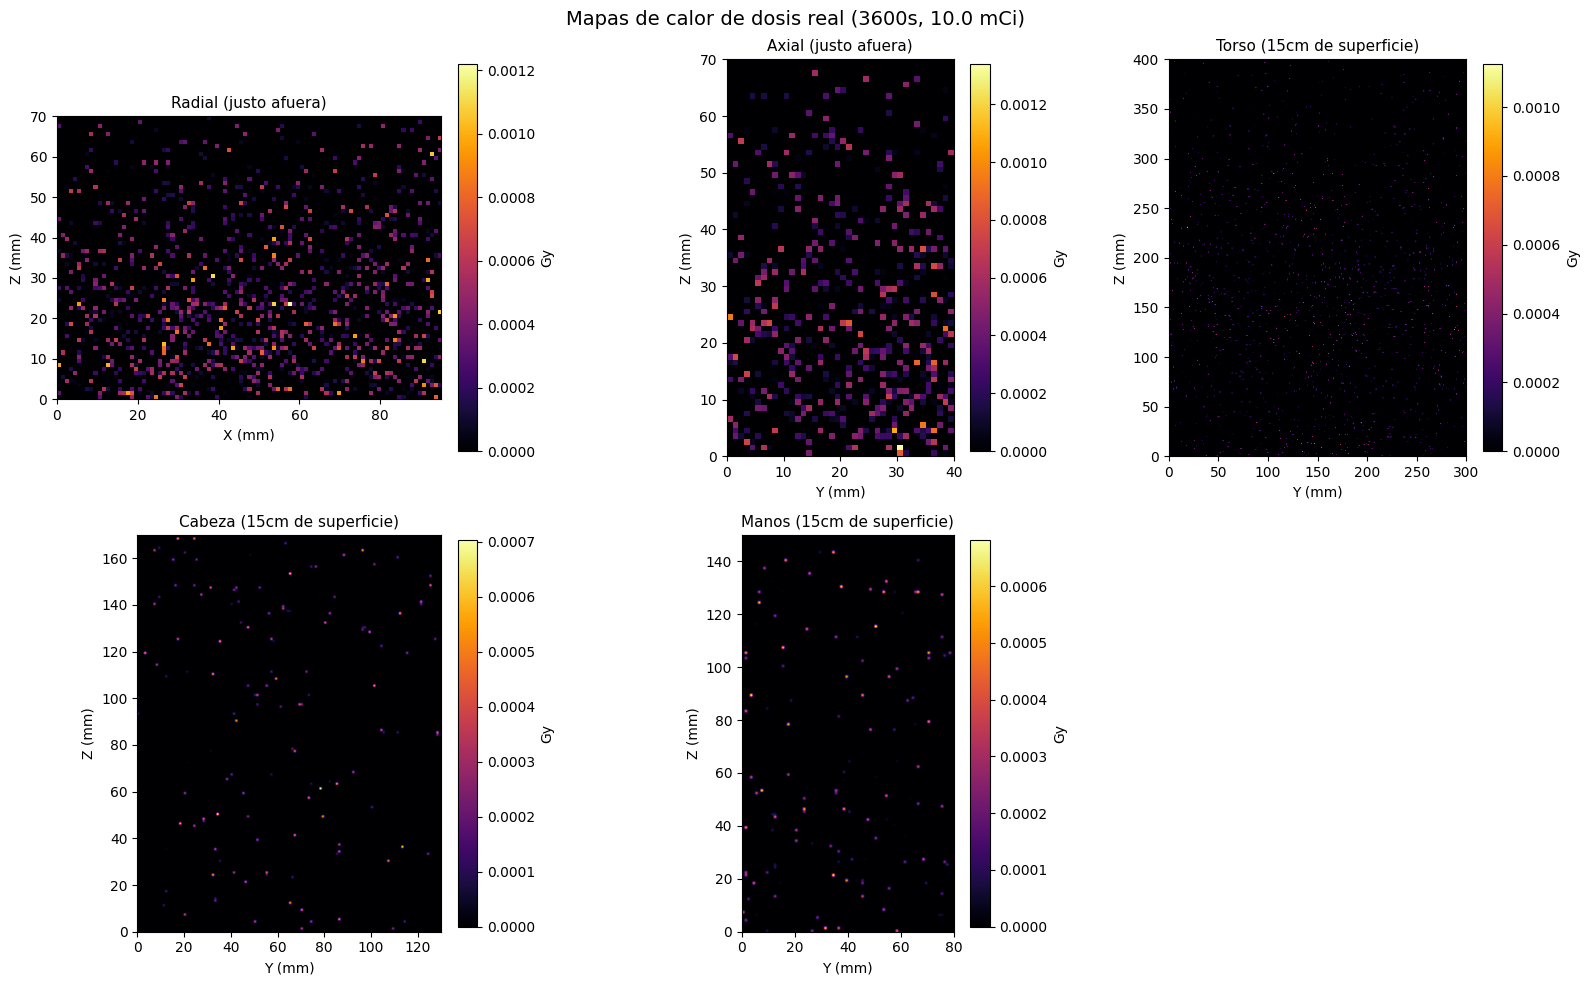

In [16]:
def mapa_calor_detector(ax, volumen, spacing_mm, titulo, unidad="Gy"):
    """Grafica la única cara real de un detector plano (una dimensión = 1 vóxel)."""
    nz, ny, nx = volumen.shape
    if nz == 1:
        datos_2d = volumen[0, :, :]
        sp_a, sp_b = spacing_mm[1], spacing_mm[2]
        etiqueta_x, etiqueta_y = "Y (mm)", "X (mm)"
    elif ny == 1:
        datos_2d = volumen[:, 0, :]
        sp_a, sp_b = spacing_mm[0], spacing_mm[2]
        etiqueta_x, etiqueta_y = "Z (mm)", "X (mm)"
    else:
        datos_2d = volumen[:, :, 0]
        sp_a, sp_b = spacing_mm[0], spacing_mm[1]
        etiqueta_x, etiqueta_y = "Z (mm)", "Y (mm)"

    extent = [0, datos_2d.shape[1] * sp_b, 0, datos_2d.shape[0] * sp_a]
    im = ax.imshow(datos_2d, origin="lower", cmap="inferno", extent=extent, aspect="equal")
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel(etiqueta_y)
    ax.set_ylabel(etiqueta_x)
    plt.colorbar(im, ax=ax, label=unidad, fraction=0.046, pad=0.04)


DETECTORES = {
    "det_palma":  "Radial (justo afuera)",
    "det_dedos": "Axial (justo afuera)",
    "det_torso":    "Torso (15cm de superficie)",
    "det_cabeza":     "Cabeza (15cm de superficie)",
    "det_manos":    "Manos (15cm de superficie)",
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, (nombre, titulo) in zip(axes, DETECTORES.items()):
    ruta_dose = buscar_archivo(CARPETA_RESULTADOS, f"dose_{nombre}", "dose")
    if ruta_dose is None:
        print(f"[AVISO] No se encontró dose_{nombre}-dose.mhd, se omite ese panel.")
        ax.set_visible(False)
        continue
    datos, spacing = leer_mhd(ruta_dose)
    datos_reales = datos * factor_escala   # escalado a actividad/tiempo real, voxel a voxel
    mapa_calor_detector(ax, datos_reales, spacing, titulo)

axes[-1].set_visible(False)  # 5 detectores en grilla 2x3 -> 1 panel sobrante

fig.suptitle(f"Mapas de calor de dosis real ({TIEMPO_EXPOSICION_S:.0f}s, {actividad_mci} mCi)",
             fontsize=14)
fig.tight_layout()
plt.show()

**Lectura de los mapas de calor:** `det_palma` y `det_dedos` muestran distribuciones densas porque están en contacto directo con el contenedor y reciben muchos impactos. En cambio, `det_torso`, `det_cabeza` y `det_manos` (a 15 cm de la superficie, tras atravesar el blindaje completo) muestran mapas con pocos puntos de color — no es un error, sino la firma visual de baja estadística: a esa distancia y con ese blindaje de por medio, muy pocos fotones simulados depositan energía ahí. Esto se cuantifica en la siguiente sección.

### 3.2 Validación estadística
Antes de interpretar cualquier valor de dosis, se evalúa la incertidumbre relativa de cada detector. El estándar en dosimetría Monte Carlo es aceptar resultados con incertidumbre menor al 10%. Valores por encima indican que se necesitan más primarios simulados para que el resultado sea confiable.

In [17]:
def incertidumbre_combinada(dosis_datos, incertidumbre_relativa_datos):
    """Combina la incertidumbre relativa por vóxel en UNA incertidumbre
    relativa total para el detector completo (propagación de error estándar)."""
    incertidumbre_absoluta = incertidumbre_relativa_datos * dosis_datos
    dosis_total_para_ratio = float(np.sum(dosis_datos))
    if dosis_total_para_ratio <= 0:
        return None
    incertidumbre_absoluta_total = float(np.sqrt(np.sum(incertidumbre_absoluta ** 2)))
    return incertidumbre_absoluta_total / dosis_total_para_ratio


UMBRAL_INCERTIDUMBRE_ACEPTABLE = 0.10  # 10%, estándar en dosimetría Monte Carlo

nombres_detectores = []
dosis_gy = []
dosis_sv = []
incertidumbres = []

for nombre, titulo in DETECTORES.items():
    ruta_dose = buscar_archivo(CARPETA_RESULTADOS, f"dose_{nombre}", "dose")
    ruta_uncert = buscar_archivo(CARPETA_RESULTADOS, f"dose_{nombre}", "dose_uncertainty")

    if ruta_dose is None:
        print(f"[AVISO] No se encontró dose_{nombre}-dose.mhd, se omite.")
        continue

    datos_dose, _ = leer_mhd(ruta_dose)

    # Gy es una cantidad POR MASA (intensiva): se promedia entre vóxeles,
    # nunca se suma (sumar multiplicaría el resultado por N_vóxeles).
    dosis_gy_real = float(np.mean(datos_dose)) * factor_escala
    dosis_sv_real = dosis_gy_real * W_R

    if ruta_uncert is not None:
        datos_uncert, _ = leer_mhd(ruta_uncert)
        incert_rel = incertidumbre_combinada(datos_dose, datos_uncert)
    else:
        incert_rel = None

    nombres_detectores.append(nombre)
    dosis_gy.append(dosis_gy_real)
    dosis_sv.append(dosis_sv_real)
    incertidumbres.append(incert_rel)

    if incert_rel is not None:
        veredicto = "✓ OK" if incert_rel <= UMBRAL_INCERTIDUMBRE_ACEPTABLE else "✗ NECESITA MÁS PRIMARIOS"
        print(f"{titulo:<28} {dosis_gy_real:.4e} Gy = {dosis_sv_real:.4e} Sv   "
              f"Incertidumbre={incert_rel*100:.1f}% {veredicto}")
    else:
        print(f"{titulo:<28} {dosis_gy_real:.4e} Gy = {dosis_sv_real:.4e} Sv   (sin dato de incertidumbre)")

Radial (justo afuera)        5.0054e-05 Gy = 5.0054e-05 Sv   Incertidumbre=3.4% ✓ OK
Axial (justo afuera)         5.5006e-05 Gy = 5.5006e-05 Sv   Incertidumbre=5.2% ✓ OK
Torso (15cm de superficie)   4.1667e-06 Gy = 4.1667e-06 Sv   Incertidumbre=2.8% ✓ OK
Cabeza (15cm de superficie)  1.8583e-06 Gy = 1.8583e-06 Sv   Incertidumbre=9.7% ✓ OK
Manos (15cm de superficie)   2.8906e-06 Gy = 2.8906e-06 Sv   Incertidumbre=10.7% ✗ NECESITA MÁS PRIMARIOS


### 3.3 Dosis por detector


La fuente emite partículas mediante decaimiento beta positivo. El positrón emitido se aniquila con un electrón del medio, produciendo dos fotones gamma de 511 keV. La dosis recibida por cada detector se expresa en sieverts. Para radiación gamma el factor de ponderación es W_R = 1, por lo que la dosis en gray y en sievert son numéricamente equivalentes.

In [18]:
def graficar_histograma_dosis(nombres, valores, incertidumbres, unidad, titulo):
    fig, ax = plt.subplots(figsize=(9, 5.5))
    colores = plt.cm.viridis(np.linspace(0.15, 0.85, len(nombres)))
    barras = ax.bar(nombres, valores, color=colores)

    valores_pos = [v for v in valores if v > 0]
    usa_log = valores_pos and (max(valores_pos) / min(valores_pos) > 100)
    if usa_log:
        ax.set_yscale("log")
        # Deja espacio arriba para las etiquetas (en log, hay que multiplicar, no sumar)
        ax.set_ylim(top=max(valores_pos) * 30)
    else:
        ax.set_ylim(top=max(valores_pos) * 1.25)

    ax.set_ylabel(f"Dosis ({unidad})")
    ax.set_title(titulo, pad=15)
    ax.tick_params(axis="x", rotation=20)

    for barra, valor, incert in zip(barras, valores, incertidumbres):
        etiqueta = f"{valor:.2e}"
        if incert is not None:
            marca = "✓" if incert <= UMBRAL_INCERTIDUMBRE_ACEPTABLE else "✗"
            etiqueta += f" ({incert*100:.0f}% {marca})"   # una sola línea, no dos
        ax.annotate(etiqueta, (barra.get_x() + barra.get_width() / 2, barra.get_height()),
                    ha="center", va="bottom", fontsize=8,
                    xytext=(0, 4), textcoords="offset points")

    fig.tight_layout()
    plt.show()

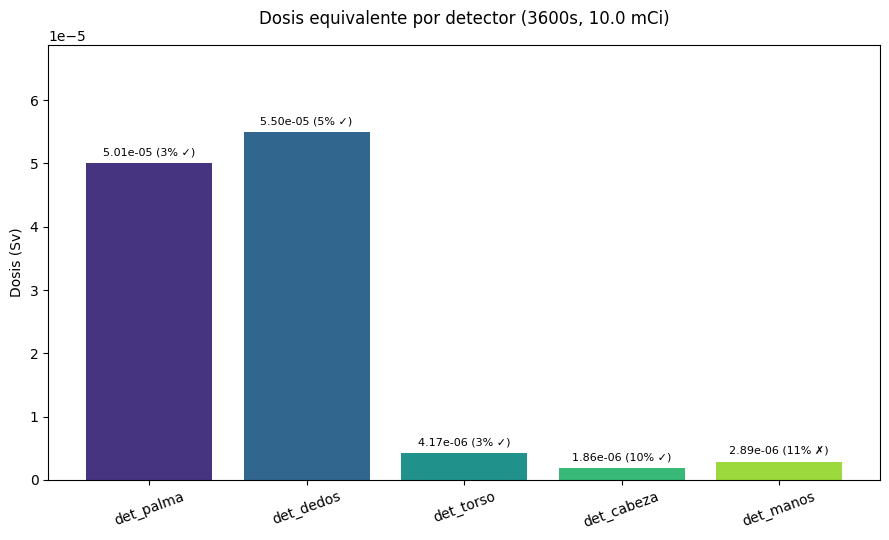

In [19]:
graficar_histograma_dosis(
    nombres_detectores, dosis_sv, incertidumbres, "Sv",
    f"Dosis equivalente por detector ({TIEMPO_EXPOSICION_S:.0f}s, {actividad_mci} mCi)"
)

### 3.4 Atenuación a través del blindaje
#### Perfil de dosis vs posición
Muestra cómo decae la dosis al atravesar cada capa del blindaje (agua → vidrio → aire → plomo → acero → aire libre), desde la fuente hasta el det_torso a 15 cm de la superficie.

In [20]:
def reagrupar_perfil(perfil, spacing_eje, radio_externo_mm, factor_reagrupado=10, modo="suma"):
    """Reagrupa (rebinning) el perfil, SOLO a partir de radio_externo_mm
    (fuera del blindaje, donde el material es homogéneo: aire).
    modo='suma'     -> para cantidades extensivas (Edep, MeV).
    modo='promedio' -> para cantidades intensivas (Dosis, Gy) — sumar Gy
                       multiplicaría el resultado por N_vóxeles agrupados."""
    n = perfil.shape[0]
    posiciones = (np.arange(n) - n / 2) * spacing_eje

    dentro_mask = np.abs(posiciones) <= radio_externo_mm
    fuera_mask = ~dentro_mask

    pos_dentro = posiciones[dentro_mask]
    val_dentro = perfil[dentro_mask]

    pos_fuera_pos = posiciones[fuera_mask & (posiciones > 0)]
    val_fuera_pos = perfil[fuera_mask & (posiciones > 0)]
    pos_fuera_neg = posiciones[fuera_mask & (posiciones < 0)]
    val_fuera_neg = perfil[fuera_mask & (posiciones < 0)]

    def _agrupar(pos, val, factor):
        n_completos = (len(val) // factor) * factor
        if n_completos == 0:
            return pos, val
        pos_r = pos[:n_completos].reshape(-1, factor).mean(axis=1)
        if modo == "promedio":
            val_r = val[:n_completos].reshape(-1, factor).mean(axis=1)
        else:
            val_r = val[:n_completos].reshape(-1, factor).sum(axis=1)
        return pos_r, val_r

    pos_fuera_pos_r, val_fuera_pos_r = _agrupar(pos_fuera_pos, val_fuera_pos, factor_reagrupado)
    pos_fuera_neg_r, val_fuera_neg_r = _agrupar(pos_fuera_neg[::-1], val_fuera_neg[::-1], factor_reagrupado)
    pos_fuera_neg_r, val_fuera_neg_r = pos_fuera_neg_r[::-1], val_fuera_neg_r[::-1]

    pos_final = np.concatenate([pos_fuera_neg_r, pos_dentro, pos_fuera_pos_r])
    val_final = np.concatenate([val_fuera_neg_r, val_dentro, val_fuera_pos_r])
    orden = np.argsort(pos_final)
    return pos_final[orden], val_final[orden]

In [21]:
def graficar_perfil_energia(datos, spacing_mm, eje, limites_geometria, titulo,
                             posicion_fuente=0.0, detectores_a_marcar=None, es_dosis=True):
    if eje == "radial":
        perfil = datos.sum(axis=(0, 1))
        spacing_eje = spacing_mm[0]
    else:
        perfil = datos.sum(axis=(1, 2))
        spacing_eje = spacing_mm[2]

    radio_externo_mm = max(r1 for r0, r1 in limites_geometria.values())
    modo = "promedio" if es_dosis else "suma"
    posiciones, perfil_reagrupado = reagrupar_perfil(perfil, spacing_eje, radio_externo_mm,
                                                       factor_reagrupado=10, modo=modo)

    piso = max(perfil_reagrupado[perfil_reagrupado > 0].min() * 0.1, 1e-12) \
        if np.any(perfil_reagrupado > 0) else 1e-12
    perfil_graficar = np.where(perfil_reagrupado > 0, perfil_reagrupado, piso)

    primera_pos = next(iter(detectores_a_marcar.values()))
    direccion = 1 if (primera_pos - posicion_fuente) >= 0 else -1

    posiciones_rel = posiciones - posicion_fuente
    mascara = (posiciones_rel * direccion) >= 0
    posiciones_rel = posiciones_rel[mascara]
    perfil_graficar = perfil_graficar[mascara]

    # Distancia SIEMPRE positiva y creciente hacia la derecha, sin importar
    # si el detector real está en +X/+Z o en -X/-Z.
    distancia_desde_fuente = posiciones_rel * direccion

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(distancia_desde_fuente, perfil_graficar, color="black", linewidth=1.2)
    ax.axhline(piso, color="gray", linestyle=":", linewidth=0.8, label="piso (sin estadística, ~0)")
    ax.axvline(0, color="tab:blue", linewidth=1.5, label="fuente (F-18)")

    colores_lineas = ["red", "darkred", "firebrick", "crimson"]
    for (etiqueta, pos_abs), color in zip(detectores_a_marcar.items(), colores_lineas):
        dist_detector = (pos_abs - posicion_fuente) * direccion
        ax.axvline(dist_detector, color=color, linestyle="--", linewidth=1,
                   label=f"centro de {etiqueta}")

    ax.set_yscale("log")
    ax.set_xlabel("Distancia desde la fuente hacia el detector (mm)")
    ax.set_ylabel("Dosis (Gy, escala log)" if es_dosis else "Energía depositada (MeV, escala log)")
    ax.set_title(titulo)

    colores_region = {"agua": "#3355ff", "vidrio": "#00cccc", "cavidad_aire": "#a8d5ff",
                       "plomo": "#7d7d7d", "acero": "#c9c9c9"}
    etiquetas_usadas = set()
    for region, (r0, r1) in limites_geometria.items():
        color = colores_region.get(region, "#dddddd")
        a = r0 - direccion * posicion_fuente if False else (r0 - posicion_fuente) if direccion == 1 else (r0 + posicion_fuente)
        # equivalente simplificado: distancia_region = r - posicion_fuente, ya orientada
        a = r0 - posicion_fuente if direccion == 1 else -(r0) - (-posicion_fuente)
        b = r1 - posicion_fuente if direccion == 1 else -(r1) - (-posicion_fuente)
        # forma robusta y simple, equivalente a lo anterior:
        a = (direccion * r0 - posicion_fuente) * direccion
        b = (direccion * r1 - posicion_fuente) * direccion
        etiqueta = region if region not in etiquetas_usadas else None
        ax.axvspan(min(a, b), max(a, b), color=color, alpha=0.4, label=etiqueta)
        etiquetas_usadas.add(region)

    ax.legend(loc="upper right", fontsize=8)
    fig.tight_layout()
    plt.show()

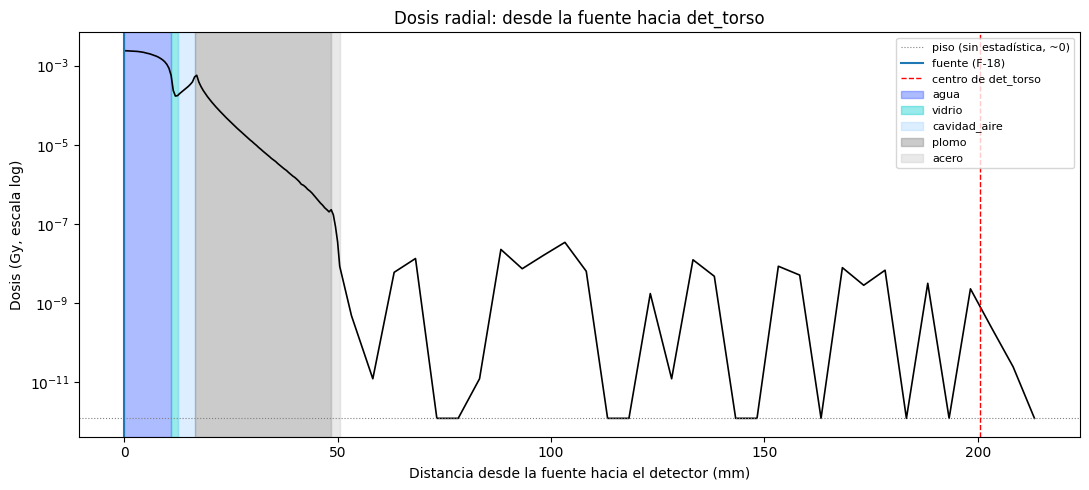

In [26]:
geometria = metadata.get("geometria", {})

POSICION_FUENTE_RADIAL_MM = 0.0

ruta_perfil_radial = buscar_archivo(CARPETA_RESULTADOS, "dose_perfil_radial", "dose")
if ruta_perfil_radial is not None and "radial_mm" in geometria:
    datos_radial, spacing_radial = leer_mhd(ruta_perfil_radial)
    limites = {k: v for k, v in geometria["radial_mm"].items() if isinstance(v, list)}
    detectores_radial = {
        "det_torso": geometria["radial_mm"].get("det_torso_centro"),
    }
    graficar_perfil_energia(datos_radial, spacing_radial, "radial", limites,
                             "Dosis radial: desde la fuente hacia det_torso",
                             posicion_fuente=POSICION_FUENTE_RADIAL_MM,
                             detectores_a_marcar=detectores_radial, es_dosis=True)
else:
    print("[AVISO] No se encontró el perfil radial o falta 'radial_mm'.")

#### Transmitancia
Fracción de la energía total emitida por la fuente que llega a cada detector. A diferencia de la dosis en Sv, no depende del factor de escala — es un cociente entre dos magnitudes de la misma simulación. Representa la fracción que llega a una región específica del espacio, no la fracción total que escapa del blindaje en todas direcciones.

$$T = \frac{E_{dep,\ detector}}{E_{total,\ emitida\ por\ la\ fuente}}$$

In [23]:
energia_media_mev = metadata["energia_media_por_decaimiento_MeV"]
energia_total_emitida_mev = n_primarios * energia_media_mev

print(f"Energía media por decaimiento (F-18): {energia_media_mev:.4f} MeV")
print(f"Energía total emitida (simulación)  : {energia_total_emitida_mev:.4e} MeV")
print()

transmitancias = []

for nombre, titulo in DETECTORES.items():
    ruta_edep = buscar_archivo(CARPETA_RESULTADOS, f"dose_{nombre}", "edep")
    if ruta_edep is None:
        print(f"[AVISO] No se encontró dose_{nombre}-edep.mhd, se omite.")
        transmitancias.append(None)
        continue

    datos_edep, _ = leer_mhd(ruta_edep)
    edep_total_mev = float(np.sum(datos_edep))   # Edep (MeV) es extensiva -> se suma, no se promedia

    transmitancia = edep_total_mev / energia_total_emitida_mev
    transmitancias.append(transmitancia)

    print(f"{titulo:<28} Transmitancia = {transmitancia:.4e}")

Energía media por decaimiento (F-18): 1.2316 MeV
Energía total emitida (simulación)  : 1.2316e+08 MeV

Radial (justo afuera)        Transmitancia = 1.3044e-06
Axial (justo afuera)         Transmitancia = 6.0358e-07
Torso (15cm de superficie)   Transmitancia = 1.9594e-06
Cabeza (15cm de superficie)  Transmitancia = 1.6094e-07
Manos (15cm de superficie)   Transmitancia = 1.3593e-07


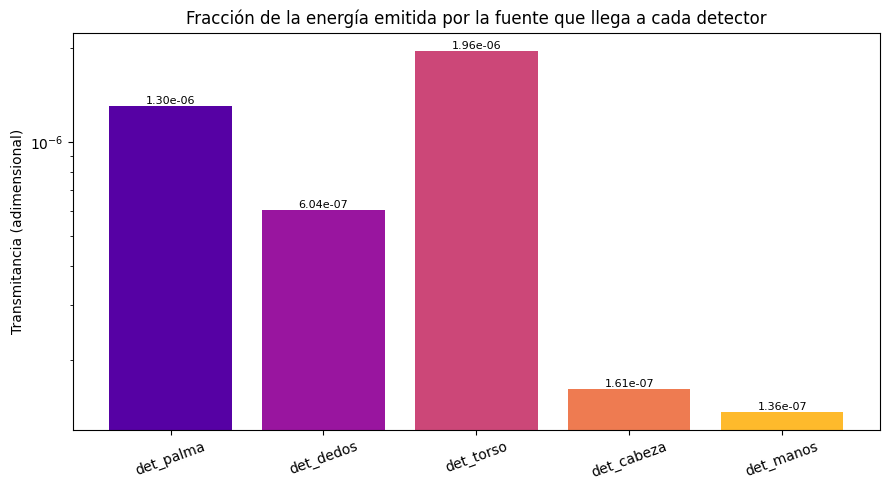

In [24]:
fig, ax = plt.subplots(figsize=(9, 5))
valores_validos = [(n, t) for n, t in zip(nombres_detectores, transmitancias) if t is not None]
nombres_t = [n for n, t in valores_validos]
valores_t = [t for n, t in valores_validos]

colores = plt.cm.plasma(np.linspace(0.15, 0.85, len(nombres_t)))
barras = ax.bar(nombres_t, valores_t, color=colores)
ax.set_yscale("log")
ax.set_ylabel("Transmitancia (adimensional)")
ax.set_title("Fracción de la energía emitida por la fuente que llega a cada detector")
ax.tick_params(axis="x", rotation=20)

for barra, valor in zip(barras, valores_t):
    ax.annotate(f"{valor:.2e}", (barra.get_x() + barra.get_width() / 2, barra.get_height()),
                ha="center", va="bottom", fontsize=8)

fig.tight_layout()
plt.show()